# 02 Descriptors, Fingerprints, and Similarity

This section turns molecules into numbers that models can process: descriptors and fingerprints. We first inspect a descriptor table, then introduce fingerprints, and finally compute Tanimoto similarity from fingerprints.

Application scenarios include similarity search, virtual screening, QSAR modeling, molecular clustering, and applicability-domain estimation. The Morgan/ECFP idea follows extended-connectivity fingerprints described by Rogers and Hahn; RDKit usage follows the RDKit fingerprint generator documentation.

## Intuition

A descriptor is like a molecule's resume: molecular weight, LogP, TPSA, hydrogen-bond donors, and hydrogen-bond acceptors. A fingerprint is like a checklist of structural fragments: if a local structure appears, the corresponding position is set to 1.

The two representations answer different questions:

- Descriptors are better for explaining global molecular properties, such as size, polarity, and hydrogen-bonding capacity.
- Fingerprints are better for comparing whether two molecules contain similar local structural fragments.

In this tutorial, Tanimoto similarity is usually computed from fingerprints, not directly from a small descriptor table. Mathematically, Tanimoto/Jaccard can be generalized to nonnegative vectors. For descriptors such as MolWt, LogP, and TPSA, one usually standardizes values first and then uses Euclidean distance, cosine similarity, Mahalanobis distance, or a model/kernel-based comparison. Otherwise, units and scales make the result hard to interpret.

## What Is a Fingerprint?

A fingerprint encodes molecular structure as a fixed-length vector. The most common teaching example is a binary fingerprint:

```text
bit = 1: a structural fragment appears
bit = 0: this structural fragment does not appear
```

This tutorial uses Morgan fingerprints. They start from each atom and expand the local environment layer by layer. `radius=2` roughly means considering local structures within two bonds around each atom. Common fingerprint families include:

| Fingerprint | Intuition | Common use |
| --- | --- | --- |
| Morgan/ECFP | Circular local environments around atoms | Similarity search, QSAR, virtual screening |
| MACCS keys | Predefined structural questions, such as functional-group presence | Fast teaching, interpretable filtering |
| RDKit topological fingerprint | Fragments enumerated along graph paths | General similarity search |
| Atom-pair fingerprint | Atom-pair types and topological distances | Longer-range structural relationships |
| Pharmacophore fingerprint | Pharmacophore features and spatial/topological relations | Drug-discovery similarity |

Different fingerprints change what "similar" means. Similarity is therefore not an absolute molecular property; it is the result of "representation + similarity formula".

## Mathematical and Chemical Definitions

Tanimoto similarity measures fingerprint overlap:

```text
T(A, B) = c / (a + b - c)
```

`a` is the number of active bits in A, `b` is the number of active bits in B, and `c` is the number of bits active in both A and B.

If fingerprints are treated as sets:

```text
A = set of structural fragments in molecule A
B = set of structural fragments in molecule B

T(A, B) = |A intersection B| / |A union B|
```

This is the set version of Jaccard similarity; in cheminformatics it is often called Tanimoto similarity. The intuition is: the more similar two molecules are, the larger the fraction of shared fragments among all fragments observed in either molecule.

Comparison with other similarity or distance choices:

| Method | Form / intuition | Good for | Limitation |
| --- | --- | --- | --- |
| Tanimoto/Jaccard | Shared fragments / total fragments | Sparse binary fingerprints | Does not know which fragments are more important; depends on fingerprint choice |
| Dice similarity | `2c / (a + b)`, emphasizes overlap | Binary set comparison | Often numerically higher than Tanimoto; not directly interchangeable across papers |
| Cosine similarity | Angle between vectors | Continuous vectors, embeddings, count vectors | Usable for binary fingerprints, but less common as the default chemical retrieval metric |
| Euclidean distance | Geometric distance | Standardized descriptor tables | Sensitive to scale; weak intuition on sparse high-dimensional bits |

Strengths: Tanimoto is simple, fast, bounded between 0 and 1, and well suited to sparse fingerprints.
Limitations: it only sees bit overlap. It does not know which fragment is mechanistically important, and it does not directly encode conformation, reaction conditions, experimental error, or mechanism.

In [1]:
from pathlib import Path

START = Path.cwd().resolve()
for candidate in [START, *START.parents]:
    if (candidate / "data").exists() and (candidate / "notebooks").exists():
        ROOT = candidate
        break
else:
    raise FileNotFoundError(
        "Cannot find the materials root. Start Jupyter from the materials directory "
        "or from one of its subdirectories."
    )

DATA = ROOT / "data"
RAW = DATA / "raw"
EXAMPLES = DATA / "examples"
RANDOM_STATE = 42

# print("materials root:", ROOT)

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from rdkit import Chem, DataStructs
from rdkit.Chem import Crippen, Descriptors, Draw, Lipinski, rdFingerprintGenerator, rdMolDescriptors
from rdkit.Chem.Scaffolds import MurckoScaffold

sns.set_theme(style="whitegrid", context="notebook")


def mol_from_smiles(smiles):
    if pd.isna(smiles):
        return None
    return Chem.MolFromSmiles(str(smiles).strip())


def canonical_smiles(smiles):
    mol = mol_from_smiles(smiles)
    if mol is None:
        return None
    return Chem.MolToSmiles(mol)


def scaffold_smiles(mol):
    scaffold = MurckoScaffold.GetScaffoldForMol(mol)
    return Chem.MolToSmiles(scaffold)


def descriptor_record(smiles):
    mol = mol_from_smiles(smiles)
    if mol is None:
        return None
    return {
        "MolWt": Descriptors.MolWt(mol),
        "MolLogP": Crippen.MolLogP(mol),
        "TPSA": rdMolDescriptors.CalcTPSA(mol),
        "HBD": Lipinski.NumHDonors(mol),
        "HBA": Lipinski.NumHAcceptors(mol),
        "RotatableBonds": Lipinski.NumRotatableBonds(mol),
        "RingCount": rdMolDescriptors.CalcNumRings(mol),
        "AromaticRings": rdMolDescriptors.CalcNumAromaticRings(mol),
        "FractionCSP3": rdMolDescriptors.CalcFractionCSP3(mol),
        "HeavyAtomCount": Descriptors.HeavyAtomCount(mol),
        "canonical_smiles": canonical_smiles(smiles),
        "scaffold": scaffold_smiles(mol),
    }


def build_esol_features():
    raw = pd.read_csv(RAW / "esol.csv")
    rows = []
    for row_id, row in raw.reset_index(drop=True).iterrows():
        desc = descriptor_record(row["smiles"])
        if desc is None:
            continue
        desc.update(
            {
                "row_id": row_id,
                "smiles": str(row["smiles"]).strip(),
                "logS": float(row["log solubility (mol/L)"]),
            }
        )
        rows.append(desc)
    return pd.DataFrame(rows)


def fingerprint_array(smiles, n_bits=1024):
    generator = rdFingerprintGenerator.GetMorganGenerator(radius=2, fpSize=n_bits)
    matrix = np.zeros((len(smiles), n_bits), dtype=np.int8)
    for idx, smi in enumerate(smiles):
        fp = generator.GetFingerprint(mol_from_smiles(smi))
        DataStructs.ConvertToNumpyArray(fp, matrix[idx])
    return matrix


DESCRIPTOR_COLUMNS = [
    "MolWt",
    "MolLogP",
    "TPSA",
    "HBD",
    "HBA",
    "RotatableBonds",
    "RingCount",
    "AromaticRings",
    "FractionCSP3",
    "HeavyAtomCount",
]

In [3]:
examples = pd.read_csv(EXAMPLES / "example_molecules.csv")
examples = examples[examples["smiles"].apply(lambda s: mol_from_smiles(s) is not None)].reset_index(drop=True)

# This cell converts each example SMILES into interpretable descriptors.
# Inspect descriptors first so that "molecules become numbers" is grounded in readable chemical quantities.
descriptor_rows = []
for _, row in examples.iterrows():
    desc = descriptor_record(row["smiles"])
    desc.update({"name": row["name"], "smiles": row["smiles"]})
    descriptor_rows.append(desc)

desc_table = pd.DataFrame(descriptor_rows)
desc_table[["name", "MolWt", "MolLogP", "TPSA", "HBD", "HBA", "RingCount", "canonical_smiles"]].round(2)

[18:40:43] SMILES Parse Error: unclosed ring for input: 'C1CC'


,name,MolWt,MolLogP,TPSA,HBD,HBA,RingCount,canonical_smiles
0,ethanol,46.07,-0.00,20.23,1,1,0,CCO
1,benzene,78.11,1.69,0.00,0,0,1,c1ccccc1
2,toluene,92.14,2.00,0.00,0,0,1,Cc1ccccc1
3,aspirin,180.16,1.31,63.60,1,3,1,CC(=O)Oc1ccccc1C(=O)O
4,ibuprofen,206.28,3.07,37.30,1,1,1,CC(C)Cc1ccc(C(C)C(=O)O)cc1
5,glucose,180.16,-3.22,110.38,5,6,1,OC[C@H]1O[C@@H](O)[C@H](O)[C@@H](O)[C@H]1O
6,caffeine,194.19,-1.03,61.82,0,3,2,Cn1c(=O)c2c(ncn2C)n(C)c1=O


## Code

The next cells compute Morgan fingerprints and pairwise Tanimoto similarity. Similarity closer to 1 means more fingerprint overlap.

Read the code in three steps:

1. Define the fingerprint rule with `GetMorganGenerator(radius=2, fpSize=1024)`.
2. Convert each SMILES into a fingerprint.
3. Use RDKit `FingerprintSimilarity` to compute pairwise Tanimoto similarity.

In [4]:
# radius controls the local environment size; fpSize controls the number of compressed bits.
generator = rdFingerprintGenerator.GetMorganGenerator(radius=2, fpSize=1024)
fps = [generator.GetFingerprint(mol_from_smiles(smi)) for smi in examples["smiles"]]

# sim[i, j] is the Tanimoto similarity between molecule i and molecule j.
sim = np.zeros((len(fps), len(fps)))
for i, fp_i in enumerate(fps):
    for j, fp_j in enumerate(fps):
        sim[i, j] = DataStructs.FingerprintSimilarity(fp_i, fp_j)

sim_df = pd.DataFrame(sim, index=examples["name"], columns=examples["name"])
sim_df.round(2)

name,ethanol,benzene,toluene,aspirin,ibuprofen,glucose,caffeine
name,,,,,,,
ethanol,1.00,0.00,0.06,0.11,0.11,0.15,0.03
benzene,0.00,1.00,0.27,0.12,0.08,0.00,0.04
toluene,0.06,0.27,1.00,0.25,0.16,0.00,0.09
aspirin,0.11,0.12,0.25,1.00,0.20,0.02,0.09
ibuprofen,0.11,0.08,0.16,0.20,1.00,0.11,0.11
glucose,0.15,0.00,0.00,0.02,0.11,1.00,0.02
caffeine,0.03,0.04,0.09,0.09,0.11,0.02,1.00


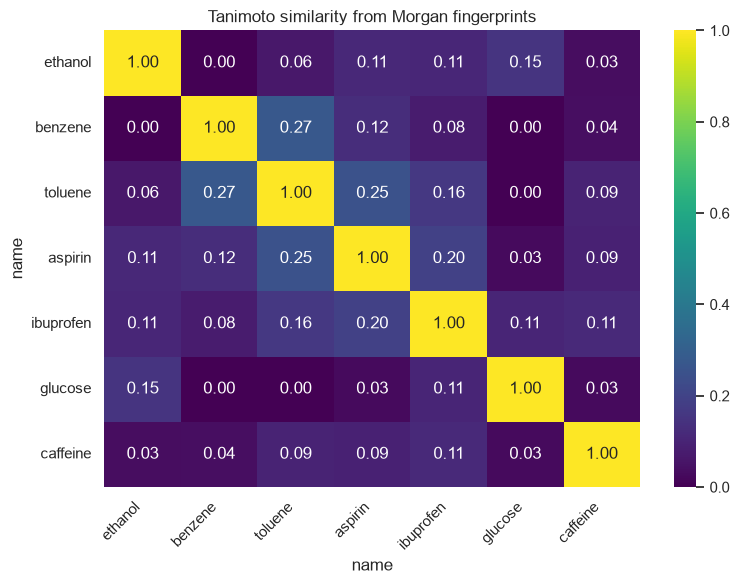

In [5]:
# The heatmap shows the similarity matrix; the diagonal is 1 because each molecule is identical to itself.
plt.figure(figsize=(8, 6))
sns.heatmap(sim_df, vmin=0, vmax=1, cmap="viridis", annot=True, fmt=".2f")
plt.title("Tanimoto similarity from Morgan fingerprints")
plt.xticks(rotation=45, ha="right")
plt.yticks(rotation=0)
plt.tight_layout()

('benzene', 'toluene') Tanimoto = 0.273


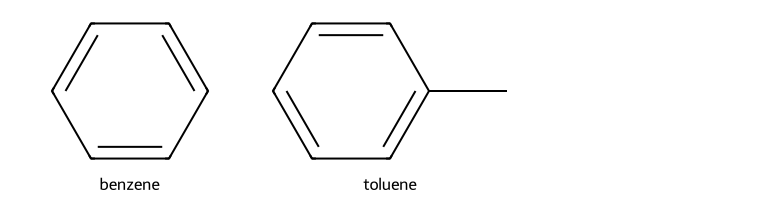

In [6]:
pair = ("benzene", "toluene")  # try ("ethanol", "glucose") or ("aspirin", "ibuprofen")
idx_a = examples.index[examples["name"] == pair[0]][0]
idx_b = examples.index[examples["name"] == pair[1]][0]

# Change pair to quickly compare numerical similarity with chemical intuition.
print(pair, "Tanimoto =", sim[idx_a, idx_b].round(3))
Draw.MolsToGridImage(
    [mol_from_smiles(examples.loc[idx_a, "smiles"]), mol_from_smiles(examples.loc[idx_b, "smiles"])],
    legends=list(pair),
    subImgSize=(260, 200),
)

## Observation Questions

1. Does the similarity between benzene and toluene match your intuition?
2. Which descriptor seems most connected to aqueous solubility?
3. Fingerprint bits are not very intuitive one by one. Why are they still useful?

### Hints

1. Benzene and toluene share an aromatic ring, so Tanimoto should be relatively high. The methyl substituent adds extra fragments, so it should not be 1.
2. Start with `MolLogP`, `TPSA`, `HBD`, and `HBA`. Solubility often relates to polarity, hydrogen-bonding capacity, and hydrophobicity, but no single descriptor fully determines it.
3. Individual bits are hard to interpret, but the full bit vector efficiently represents many local structural fragments, making it useful for similarity search and machine-learning input.

## Summary

Descriptors are easier to interpret; fingerprints are better at capturing local structure. Tanimoto similarity is a fingerprint-based similarity metric, not the complete meaning of chemical similarity.